Step 2: Linear regression

Predict numerical variables

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline




Read data

In [56]:
file = 'hourly_columbia_weather.parquet'

# Read parquet into dataframe
df = pd.read_parquet(file)

print(df.head())

                     temp  dwpt  rhum  prcp   wdir  wspd    pres  coco  \
2024-01-02 00:00:00  10.0   1.1  54.0   0.0   20.0  14.8  1019.2   3.0   
2024-01-02 01:00:00   8.9  -2.1  46.0   0.0  350.0  13.0  1020.2   3.0   
2024-01-02 02:00:00   6.7  -3.8  47.0   0.0    2.0   7.0  1021.2   3.0   
2024-01-02 03:00:00   6.1  -3.8  49.0   0.0  350.0   7.6  1022.2   2.0   
2024-01-02 04:00:00   5.6  -4.3  49.0   0.0  350.0   7.6  1022.8   3.0   

                     prcp_flag       day_sin  ...  wspd_roll12  prcp_roll3  \
2024-01-02 00:00:00          0 -9.634256e-12  ...     9.116667         0.0   
2024-01-02 01:00:00          0  2.588190e-01  ...     9.900000         0.0   
2024-01-02 02:00:00          0  5.000000e-01  ...    10.533333         0.0   
2024-01-02 03:00:00          0  7.071068e-01  ...    11.116667         0.0   
2024-01-02 04:00:00          0  8.660254e-01  ...    10.816667         0.0   

                     prcp_roll6  prcp_roll12  dwpt_roll3  dwpt_roll6  \
2024-01-02 00:

In [57]:
print(df.columns)

Index(['temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'coco',
       'prcp_flag', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
       'year_cos', 'wdir_sin', 'wdir_cos', 'temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24', 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6', 'temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12'],
      dtype='object')


Prepare data, split into x and y

In [58]:
# defining target (Y) and explanatory variables (X)
exclude_reg = ['wdir', 'coco', 'prcp_flag']
exclude_time = exclude_reg + ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
                               'year_cos']
exclude_lag = exclude_reg + [ 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6']
exclude_roll = exclude_reg + ['temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12']
exclude_temp = exclude_reg + ['temp_roll3', 'temp_roll6', 'temp_roll12', 'temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24']

target_name = 'temp'
###
# edit exclusion
###
exclude = exclude_reg + [target_name] + ['dwpt']
X = df.drop(columns=exclude)
Y = df[target_name]


Train/test split

In [59]:
# train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# fitting a RF model
pipe = make_pipeline(
    StandardScaler(),   
    LinearRegression()
)

# standardize X (not Y)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

pipe.fit(X_train, Y_train)

,steps,"[('standardscaler', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


Get predictions

In [60]:
# getting forecasts for the test set
y_pred = pipe.predict(X_test)

# computing metrics
r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)


In [61]:
print(f'R2: \t{r2:.4f}')
print(f'MAE: \t{mae:.4f}')
print(f'MSE:  \t{mse:.4f}')
print(f'RMSE: \t{rmse:.4f}')


R2: 	0.9958
MAE: 	0.4020
MSE:  	0.3053
RMSE: 	0.5526


Plot performance

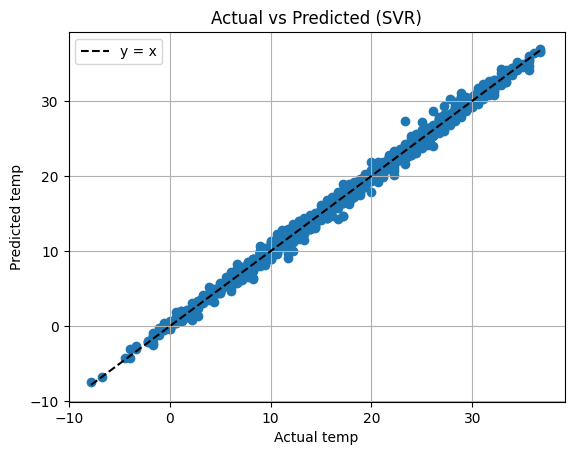

In [62]:
# plot the predicted values against the true values
plt.scatter(Y_test, y_pred)
# plot y=x for reference
mn = min(Y_test.min(), y_pred.min())
mx = max(Y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn,mx],linestyle='--', label='y = x', color='black')
plt.legend()
plt.xlabel('Actual temp')
plt.ylabel('Predicted temp')
plt.title('Actual vs Predicted (SVR)')
plt.grid(True)
plt.show()


SHAP

In [ ]:
# 5. Initialize the SHAP Linear Explainer
explainer = shap.Explainer(pipe, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# shap_values[0] for class 0, shap_values[1] for class 1
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())  # Class 1 (e.g., rain)